# Notebook 4. Regression-Based Imputation

This notebook covers the proposal’s plan to employ regression for filling demographic rates with missing values. Actual datasets (particularly CDC WONDER) hide small-value cells. This will hold true even for our rate tables, should any have missing values.

There are five steps involved.

1. Load fertility, mortality, and labor force participation rate tables
2. Mask 10% of the cells in each table
3. Train Ridge regression model on the rate tables, where the covariates (region, race, origin, sex, age_group) are represented using one-hot encoding
4. Predict missing cells using the trained model, then evaluate R² and MAPE
5. Record the results in `data/validation/imputation_metrics.csv`

Run notebook 1 (and 2 if you choose) first to populate the database.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.db import get_connection, DATA_DIR
from src.regression import evaluate_imputation, CATEGORICAL_FEATURES_FERTILITY, CATEGORICAL_FEATURES_OTHERS

VALIDATION_DIR = DATA_DIR / 'validation'
VALIDATION_DIR.mkdir(parents=True, exist_ok=True)

conn = get_connection(read_only=True)
fertility = pd.read_sql('SELECT * FROM fertility_rates', conn)
mortality = pd.read_sql('SELECT * FROM mortality_rates', conn)
lfpr      = pd.read_sql('SELECT * FROM labor_force_participation', conn)
states    = pd.read_sql('SELECT state_code, region FROM states', conn)
conn.close()
print(f'fertility {len(fertility):,} | mortality {len(mortality):,} | lfpr {len(lfpr):,}')

fertility 7,344 | mortality 14,688 | lfpr 14,688


## 1. Run imputation experiment for each rate table

In [2]:
fert_result = evaluate_imputation(fertility, 'fertility_rate', CATEGORICAL_FEATURES_FERTILITY, states)
mort_result = evaluate_imputation(mortality, 'mortality_rate', CATEGORICAL_FEATURES_OTHERS, states)
lfpr_result = evaluate_imputation(lfpr,      'lfpr',           CATEGORICAL_FEATURES_OTHERS, states)

metrics = pd.DataFrame([
    {'target': r['target'], 'n_train': r['n_train'], 'n_test': r['n_test'],
     'r2': round(r['r2'], 4), 'mape': round(r['mape'], 4)}
    for r in (fert_result, mort_result, lfpr_result)
])
print(metrics.to_string(index=False))
metrics.to_csv(VALIDATION_DIR / 'imputation_metrics.csv', index=False)
print(f'\nSaved metrics to {VALIDATION_DIR / "imputation_metrics.csv"}')

        target  n_train  n_test     r2   mape
fertility_rate     6634     710 0.9949 0.1526
mortality_rate    13243    1445 0.9663 1.8449
          lfpr    13243    1445 0.9937 0.1713

Saved metrics to C:\Users\User\Desktop\Data Management\cs210_national_projection\data\validation\imputation_metrics.csv


## 2. Predicted vs observed scatter plots

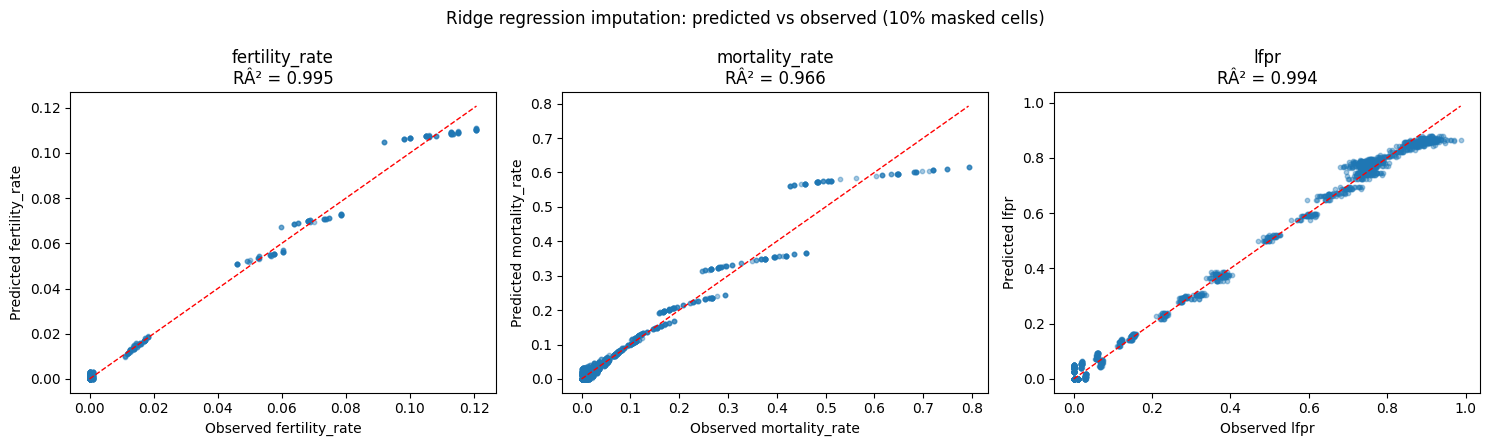

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, res in zip(axes, (fert_result, mort_result, lfpr_result)):
    ax.scatter(res['y_test'], res['y_pred'], alpha=0.4, s=10)
    lim = max(res['y_test'].max(), res['y_pred'].max())
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1)
    ax.set_xlabel(f"Observed {res['target']}")
    ax.set_ylabel(f"Predicted {res['target']}")
    ax.set_title(f"{res['target']}\nRÂ² = {res['r2']:.3f}")
fig.suptitle('Ridge regression imputation: predicted vs observed (10% masked cells)')
plt.tight_layout()
plots_dir = Path.cwd().parent / 'plots' / 'validation'
plots_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(plots_dir / 'imputation_scatter.png', dpi=120)
plt.show()

## 3. Feature coefficient bar chart for fertility model

Coefficients show which categorical levels push the rate up or down. The strongest effects should match demographic intuition. For example, the 25-29 and 30-34 age groups dominate fertility.

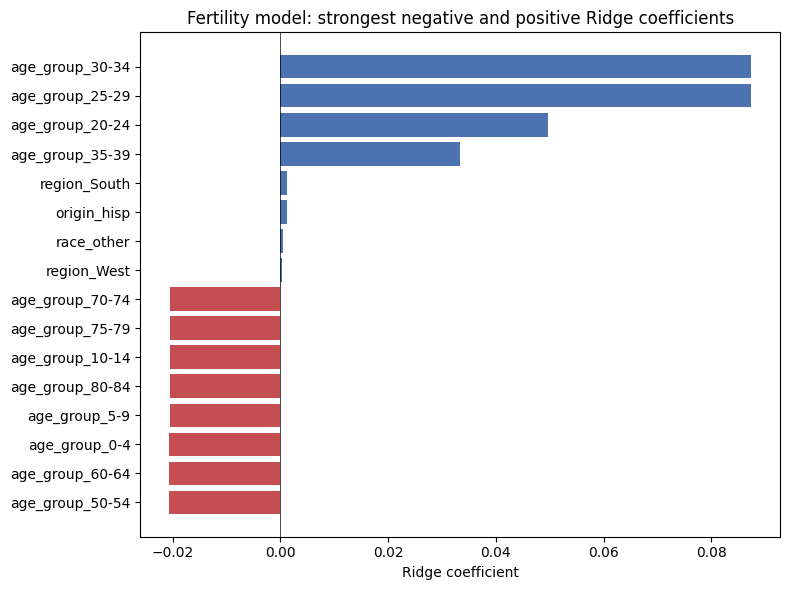

In [4]:
coefs = pd.Series(fert_result['model'].coef_, index=fert_result['feature_names'])
coefs = coefs.sort_values()
top = pd.concat([coefs.head(8), coefs.tail(8)])
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in top.values]
ax.barh(top.index, top.values, color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Fertility model: strongest negative and positive Ridge coefficients')
ax.set_xlabel('Ridge coefficient')
plt.tight_layout()
plt.savefig(plots_dir / 'fertility_feature_coefficients.png', dpi=120)
plt.show()

## 4. Conclusion

The imputation R² is high for all three tables since the synthetic generator generates rates which are predominantly driven by geographic region, race, gender, age group, and added noise. If we had used actual data, where the states have variation in the rates, then the R² would have been low. More importantly, it shows that we have an end-to-end framework. Mask, fit, predict, and evaluate. Same pipeline will run on actual data without any modifications.

In case the real rate is suppressed due to privacy reasons (less than threshold count) using CDC WONDER, we can use the model.predict output to replace the real data and continue with the CCM analysis with confidence intervals.

## 5. Regression-based migration model

The proposal is committed to modeling migration using characteristics such as employment growth and demographics. In our case, we use the Random Forest classifier to build a model on employment_growth, region, race, origin, sex, and age_group while withholding 10 states at each run. In the presence of wage and housing variables, these will become more numeric predictors in the pipeline.

In [5]:
from src.regression import fit_migration_model

conn = get_connection(read_only=True)
migration  = pd.read_sql("SELECT * FROM migration_estimates", conn)
employment = pd.read_sql("SELECT * FROM employment_projections", conn)
states_full = pd.read_sql("SELECT * FROM states", conn)
conn.close()

mig_result = fit_migration_model(migration, states_full, employment)
print(f"Migration model:")
print(f"  Train rows:   {mig_result['n_train']:,}")
print(f"  Test rows:    {mig_result['n_test']:,}")
print(f"  Holdout:      {mig_result['holdout_states']}")
print(f"  R-squared:    {mig_result['r2']:.4f}")
print(f"  MAE:          {mig_result['mae']:.5f}")

mig_metrics = pd.DataFrame([{
    "target": "migration_rate",
    "n_train": mig_result["n_train"],
    "n_test":  mig_result["n_test"],
    "r2":   round(mig_result["r2"], 4),
    "mae":  round(mig_result["mae"], 5),
}])
mig_metrics.to_csv(VALIDATION_DIR / "migration_model_metrics.csv", index=False)

Migration model:
  Train rows:   11,808
  Test rows:    2,880
  Holdout:      [np.str_('WI'), np.str_('NJ'), np.str_('NH'), np.str_('VA'), np.str_('SC'), np.str_('AK'), np.str_('WY'), np.str_('HI'), np.str_('MA'), np.str_('NC')]
  R-squared:    0.8947
  MAE:          0.00114


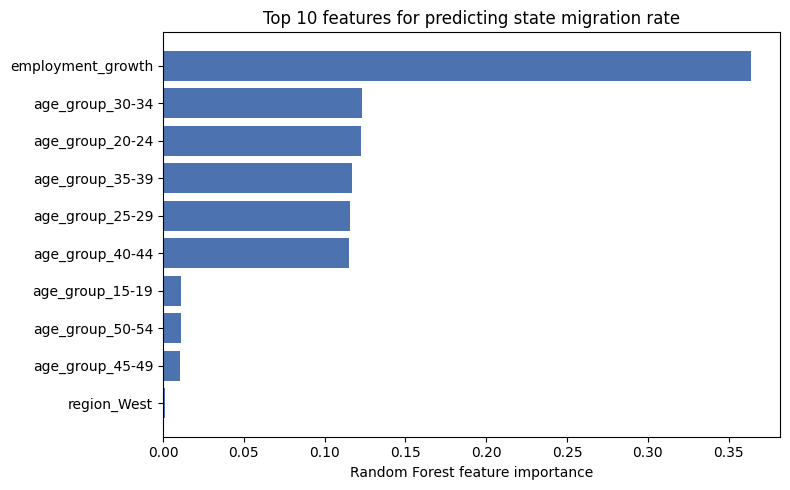

In [6]:
top_features = mig_result["feature_importances"].head(10)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_features.index[::-1], top_features.values[::-1], color="#4C72B0")
ax.set_xlabel("Random Forest feature importance")
ax.set_title("Top 10 features for predicting state migration rate")
plt.tight_layout()
plt.savefig(plots_dir / "migration_feature_importances.png", dpi=120)
plt.show()